# Home Credit V2: Consortium & Deep Feature Engineering
This notebook trains a 3-model Consortium on the 139-column Home Credit V2 dataset, splitting features into External (BFS) and Internal (RPS) subsets.

In [4]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import shap
from IPython.display import display
from sklearn.metrics import roc_auc_score, roc_curve

# Add project root to sys.path
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '../')))

from python.training.train_credit import run as train_credit
from python.training.features import CREDIT_DEFAULT_TARGET, prepare_features
from python.scoring.scoring import probability_to_bfs

import warnings
warnings.filterwarnings('ignore')

c:\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load the V2 Dataset & EDA

In [5]:
DATA_PATH = r'd:\z-business\dummtdatasets\csv\homecredit_engineered_v2.csv'
df = pd.read_csv(DATA_PATH)

print(f"Dataset Shape: {df.shape}")
print(f"Target '{CREDIT_DEFAULT_TARGET}' Default Rate: {df[CREDIT_DEFAULT_TARGET].mean()*100:.2f}%")
display(df.head())

Dataset Shape: (307511, 141)
Target 'will_default' Default Rate: 8.07%


,SK_ID_CURR,will_default,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,...,cc_mean_payment_total,cc_mean_drawings_count,cc_mean_credit_limit,cc_mean_receivable_principal,cc_mean_min_regularity,cc_utilisation,pos_max_dpd,pos_max_dpd_def,pos_mean_dpd,pos_mean_instalment_future
0,100002,1,0,202500.0,406597.5,24700.5,1.0,2,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,15.000000
1,100003,0,0,270000.0,1293502.5,35698.5,2.0,1,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,5.785714
2,100004,0,0,67500.0,135000.0,6750.0,1.0,2,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,2.250000
3,100006,0,0,135000.0,312682.5,29686.5,2.0,2,0,0,...,0.0,0.0,270000.0,0.0,0.0,0.0,0.0,0.0,0.0,8.650000
4,100007,0,0,121500.0,513000.0,21865.5,1.0,2,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,8.969697


In [6]:
# Create 'age_group' as our protected attribute for fairness auditing
df['age_group'] = pd.cut(df['age'], bins=[0, 30, 50, 100], labels=['<30', '30-50', '>50'])
print("Age Group Distribution:")
print(df['age_group'].value_counts(dropna=False))

Age Group Distribution:
age_group
30-50    158849
>50      103641
<30       45021
Name: count, dtype: int64


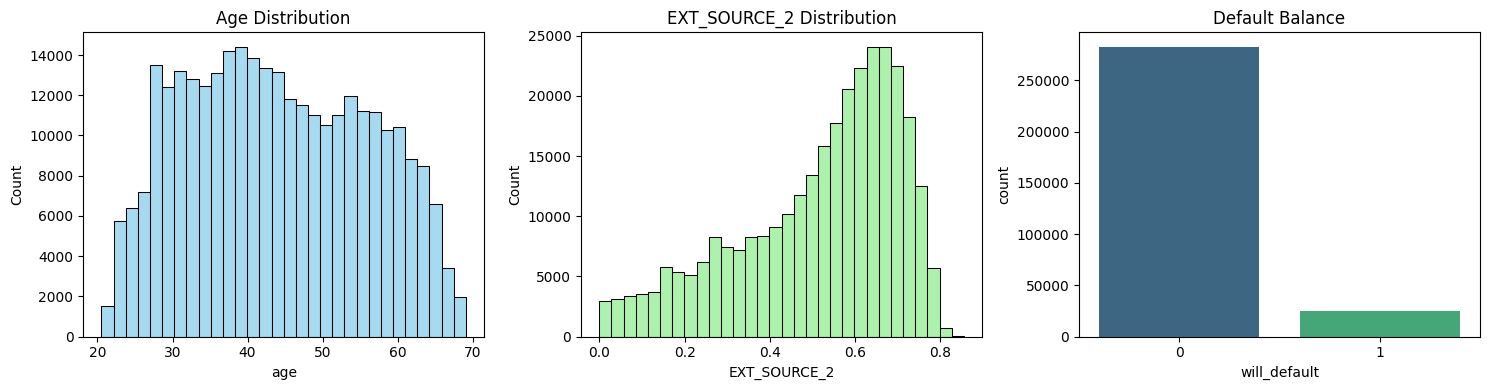

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(x=df['age'], bins=30, ax=axes[0], color='skyblue').set_title('Age Distribution')
sns.histplot(x=df['EXT_SOURCE_2'], bins=30, ax=axes[1], color='lightgreen').set_title('EXT_SOURCE_2 Distribution')
sns.countplot(x=CREDIT_DEFAULT_TARGET, data=df, ax=axes[2], palette='viridis').set_title('Default Balance')
plt.tight_layout()
plt.show()

## 2. Consortium Feature Mapping (63 Features)
We split the 63 V2 features into the External Demographic model (BFS) and the Internal Behavioral model (RPS).

In [8]:
all_cols = list(df.columns)
all_cols.remove('SK_ID_CURR')
all_cols.remove('will_default')
if 'age_group' in all_cols:
    all_cols.remove('age_group')
if 'fairness_weights' in all_cols:
    all_cols.remove('fairness_weights')

# =========================================================
# 1. BFS (Behavioural Finance Score) Model
# Purpose: External & Demographic Risk — who is this person?
# Sources used:
#  - application_train.csv:
#      Age, Income, Credit, Annuity (base numerics)
#      LTV ratio, debt/income ratio, annuity/income ratio (derived)
#      Owns car/realty (asset collateral)
#      Children/family members (dependency stress)
#      Region rating, city mismatch flags (geographic instability)
#      Social circle default rates (social risk contagion)
#      Credit bureau enquiries (hard-pull desperation)
#      Days since phone/ID change (recency signals)
#      One-Hot: Education, Housing, Occupation, Gender, Income type, Family status
#  - EXT_SOURCE_1/2/3, ext_source_product, ext_source_mean (external bureau scores)
#  - bureau.csv: external bank debts, limits, active counts, max overdue, utilisation
#  - bureau_balance.csv: monthly DPD status history (overdue rate, recent arrears)
# =========================================================
CREDIT_BFS_FEATURES_V2 = [c for c in all_cols if
    # One-Hot demographic flags
    c.startswith('NAME_') or c.startswith('OCCUPATION_') or c.startswith('CODE_GENDER')
    # External bureau scores and interactions
    or c.startswith('EXT_SOURCE') or c in ['ext_source_product', 'ext_source_mean']
    # External credit history (bureau tables)
    or c.startswith('bureau_') or c.startswith('bb_')
    # Application base & derived features
    or c in [
        'age', 'years_employed',
        'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY',
        'debt_income_ratio', 'annuity_income_ratio', 'ltv_ratio',
        'owns_car', 'owns_realty',
        'CNT_CHILDREN', 'CNT_FAM_MEMBERS',
        'REGION_RATING_CLIENT',
        'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY',
        'social_circle_default_rate_30', 'social_circle_default_rate_60',
        'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR',
        'days_last_phone_change', 'days_id_publish', 'has_bureau_history'
    ]
]

# =========================================================
# 2. RPS (Repayment Propensity Score) Model
# Purpose: Internal Behavioral & Cashflow Risk — how do they actually repay?
# Sources used:
#  - installments_payments.csv:
#      Days late (max, mean), payment fractions
#      Recency-weighted lateness (recent late payments penalised more)
#      Last 6-month payment fraction only
#  - credit_card_balance.csv:
#      ATM cash advances, CC DPD, balance, payment total
#      CC utilisation ratio (balance / limit)
#      Drawing count (spending intensity)
#  - POS_CASH_balance.csv:
#      Max DPD, defined DPD, mean DPD (internal point-of-sale)
#  - previous_application.csv:
#      Refusal/approval counts, grant ratio
#      Down payment amount & rate (commitment level)
#      Recency of most recent internal decision
# =========================================================
CREDIT_RPS_FEATURES_V2 = [c for c in all_cols if
    c.startswith('prev_') or c.startswith('inst_')
    or c.startswith('cc_') or c.startswith('pos_')
    or c in ['has_previous_application', 'has_installment_history', 'has_cc_history', 'has_pos_history']
]

# =========================================================
# 3. Credit Default (Master) Model
# Purpose: Predict ultimate probability of default.
# Sources used: ALL features from both BFS and RPS combined.
# =========================================================
CREDIT_DEFAULT_FEATURES_V2 = all_cols

# Verify no overlap and no missing features
bfs_set = set(CREDIT_BFS_FEATURES_V2)
rps_set = set(CREDIT_RPS_FEATURES_V2)
overlap = bfs_set & rps_set
unassigned = set(all_cols) - bfs_set - rps_set

print(f'BFS Feature Count : {len(CREDIT_BFS_FEATURES_V2)}')
print(f'BFS Features      : {CREDIT_BFS_FEATURES_V2}\n')
print(f'RPS Feature Count : {len(CREDIT_RPS_FEATURES_V2)}')
print(f'RPS Features      : {CREDIT_RPS_FEATURES_V2}\n')
print(f'Total (Default)   : {len(CREDIT_DEFAULT_FEATURES_V2)}')
print(f'BFS/RPS Overlap   : {overlap}  ← should be empty')
print(f'Unassigned cols   : {unassigned}  ← assigned to Default only')

BFS Feature Count : 95
BFS Features      : ['CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR', 'age', 'years_employed', 'debt_income_ratio', 'annuity_income_ratio', 'ltv_ratio', 'ext_source_product', 'ext_source_mean', 'social_circle_default_rate_30', 'social_circle_default_rate_60', 'owns_car', 'owns_realty', 'days_last_phone_change', 'days_id_publish', 'NAME_EDUCATION_TYPE_Academic degree', 'NAME_EDUCATION_TYPE_Higher education', 'NAME_EDUCATION_TYPE_Incomplete higher', 'NAME_EDUCATION_TYPE_Lower secondary', 'NAME_EDUCATION_TYPE_Secondary / secondary special', 'NAME_EDUCATION_TYPE_nan', 'NAME_HOUSING_TYPE_Co-op apartment', 'NAME_HOUSING_TYPE_House / apartment', 'NAME_HOUSING_TYPE_Municipal apartment', 'NAME_HOUSING_TYPE_Office apartment', 'NA

## 3. Optuna Hyperparameter Tuning
Run Optuna trials to find the best XGBoost parameters for the V2 features.

In [9]:
from python.training.optuna_tuner import tune_credit

print("=== Tuning Credit Default Model ===")
best_params_default = tune_credit(df=df, feature_cols=CREDIT_DEFAULT_FEATURES_V2, n_trials=5, run_name="homecredit_default_152")
print(f"\nBest Default Params: {best_params_default}\n")

print("=== Tuning Credit BFS Model ===")
best_params_bfs = tune_credit(df=df, feature_cols=CREDIT_BFS_FEATURES_V2, n_trials=5, run_name="homecredit_bfs_optuna_152")
print(f"\nBest BFS Params: {best_params_bfs}\n")

print("=== Tuning Credit RPS Model ===")
best_params_rps = tune_credit(df=df, feature_cols=CREDIT_RPS_FEATURES_V2, n_trials=5, run_name="homecredit_rps_optuna_152")
print(f"\nBest RPS Params: {best_params_rps}\n")

=== Tuning Credit Default Model ===

Best Default Params: {'n_estimators': 600, 'learning_rate': 0.0223421169350074, 'max_depth': 7, 'min_child_weight': 12, 'subsample': 0.7095132090909638, 'colsample_bytree': 0.8254003669143013, 'reg_alpha': 0.14045346099148712, 'reg_lambda': 0.05776644553934343, 'objective': 'binary:logistic', 'eval_metric': 'auc', 'random_state': 42, 'n_jobs': -1}

=== Tuning Credit BFS Model ===

Best BFS Params: {'n_estimators': 900, 'learning_rate': 0.019654111696355947, 'max_depth': 8, 'min_child_weight': 19, 'subsample': 0.7144091857222208, 'colsample_bytree': 0.8055706687367183, 'reg_alpha': 1.3574458682927237, 'reg_lambda': 0.038519196947179826, 'objective': 'binary:logistic', 'eval_metric': 'auc', 'random_state': 42, 'n_jobs': -1}

=== Tuning Credit RPS Model ===

Best RPS Params: {'n_estimators': 700, 'learning_rate': 0.050714299318469554, 'max_depth': 5, 'min_child_weight': 4, 'subsample': 0.8665836155680797, 'colsample_bytree': 0.848243155461395, 'reg_alp

## 4. Train Consortium Pipeline (Train/Val/Test)
We use the core `train_credit` script which enforces the rigorous 70/15/15 validation split and exports the models to the artifacts directory.

## Manual Level 2 (In-Processing) Bias Mitigation
Here we compute the `sample_weights` for the training phase manually. This allows us to inspect the weights generated for each demographic group and cap extreme outliers before feeding them to XGBoost.

In [10]:
from python.training.bias_mitigation import compute_fairness_weights

# 1. Compute Level 2 fairness weights manually
df['fairness_weights'] = compute_fairness_weights(
    y_true=df[CREDIT_DEFAULT_TARGET], 
    protected_attr=df['age_group'],
    strategy="equalize_groups"
)

# 2. Inspect the weights (always a good idea!)
print("Weight distribution before clipping:")
print(df.groupby('age_group')['fairness_weights'].describe())

# 3. Clip extreme weights (e.g. cap at 5.0) to prevent severe overfitting
df['fairness_weights'] = df['fairness_weights'].clip(upper=5.0)
print("\nWeights clipped.")

Weight distribution before clipping:
              count      mean       std       min       25%       50%  \
age_group                                                               
<30         45021.0  2.632496  3.976737  1.202030  1.202030  1.202030   
30-50      158849.0  0.646855  0.994848  0.340679  0.340679  0.340679   
>50        103641.0  0.832114  1.258994  0.522154  0.522154  0.522154   

                75%        max  
age_group                       
<30        1.202030  13.687690  
30-50      0.340679   3.879367  
>50        0.522154   5.945847  

Weights clipped.


## Automated Level 1 (Post-Processing) Mitigation

**Note on Level 1:** You'll notice below that we simply pass `protected_attr_col="age_group"` to the training functions. 

By doing this, **Level 1 mitigation (Threshold Optimization)** is fully automated inside the `train_credit` script. After the model finishes training on the 70% dev set, it runs on the 15% blind Test Set and automatically searches for the optimal decision thresholds for *each individual demographic group* to ensure maximum fairness (e.g. demographic parity). The optimized thresholds are then returned in the results dictionary.

In [3]:
print("=== Training Credit Default Model ===")
res_default = train_credit(
    df=df, run_name="homecredit_default", 
    feature_cols=CREDIT_DEFAULT_FEATURES_V2, 
    xgb_params=best_params_default,
    protected_attr_col="age_group",
    sample_weight_col="fairness_weights"
)

print("\n=== Training Credit BFS Model ===")
res_bfs = train_credit(
    df=df, run_name="homecredit_bfs", 
    feature_cols=CREDIT_BFS_FEATURES_V2, 
    xgb_params=best_params_bfs,
    protected_attr_col="age_group",
    sample_weight_col="fairness_weights"
)

print("\n=== Training Credit RPS Model ===")
res_rps = train_credit(
    df=df, run_name="homecredit_rps", 
    feature_cols=CREDIT_RPS_FEATURES_V2, 
    xgb_params=best_params_rps,
    protected_attr_col="age_group",
    sample_weight_col="fairness_weights"
)

=== Training Credit Default Model ===


NameError: name 'train_credit' is not defined

## 4. Inference & Score Conversion
Predict the raw probabilities, apply `probability_to_bfs()`, and evaluate ROC AUC!

In [11]:
# For inference, we use the train_test_split logic equivalent to what train_credit did 
# (so we don't cheat by evaluating on train data)
from sklearn.model_selection import train_test_split
_, test_df = train_test_split(df, test_size=0.15, random_state=42, stratify=df['will_default'])

X_test_default = prepare_features(test_df, CREDIT_DEFAULT_FEATURES_V2)
X_test_bfs = prepare_features(test_df, CREDIT_BFS_FEATURES_V2)
X_test_rps = prepare_features(test_df, CREDIT_RPS_FEATURES_V2)

# Default
model_default = xgb.XGBClassifier()
model_default.load_model(res_default['model_path'])
test_df['prob_default'] = model_default.predict_proba(X_test_default)[:, 1]

# BFS
model_bfs = xgb.XGBClassifier()
model_bfs.load_model(res_bfs['model_path'])
test_df['prob_bfs'] = model_bfs.predict_proba(X_test_bfs)[:, 1]
test_df['bfs_score_300_900'] = [probability_to_bfs(p) for p in test_df['prob_bfs']]

# RPS
model_rps = xgb.XGBClassifier()
model_rps.load_model(res_rps['model_path'])
test_df['prob_rps'] = model_rps.predict_proba(X_test_rps)[:, 1]

def rps_label(prob):
    if prob <= 0.20: return 'HIGH_PROPENSITY'
    if prob <= 0.50: return 'MEDIUM_PROPENSITY'
    return 'LOW_PROPENSITY'
test_df['rps_label'] = [rps_label(p) for p in test_df['prob_rps']]

display(test_df[['will_default', 'prob_default', 'bfs_score_300_900', 'rps_label']].head(10))

NameError: name 'res_default' is not defined

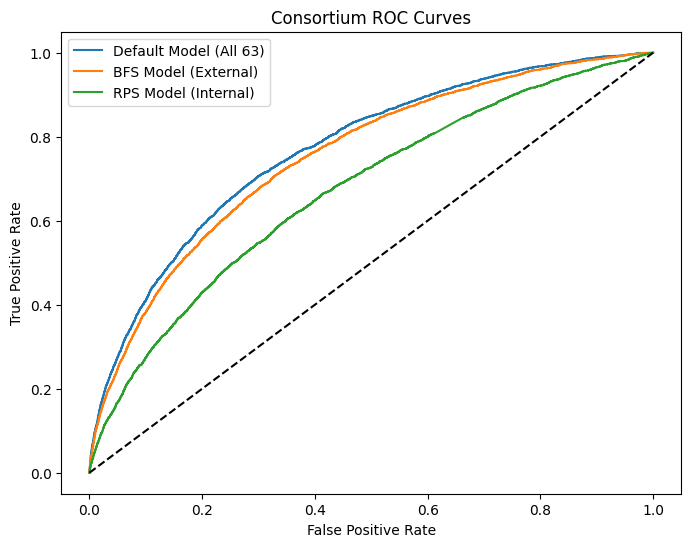

In [10]:
fpr_def, tpr_def, _ = roc_curve(test_df['will_default'], test_df['prob_default'])
fpr_bfs, tpr_bfs, _ = roc_curve(test_df['will_default'], test_df['prob_bfs'])
fpr_rps, tpr_rps, _ = roc_curve(test_df['will_default'], test_df['prob_rps'])

plt.figure(figsize=(8, 6))
plt.plot(fpr_def, tpr_def, label=f"Default Model (All 63)")
plt.plot(fpr_bfs, tpr_bfs, label=f"BFS Model (External)")
plt.plot(fpr_rps, tpr_rps, label=f"RPS Model (Internal)")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Consortium ROC Curves')
plt.legend()
plt.show()

## 5. Global Feature Importance (SHAP)
What drives the master Credit Default model?

Calculating SHAP...


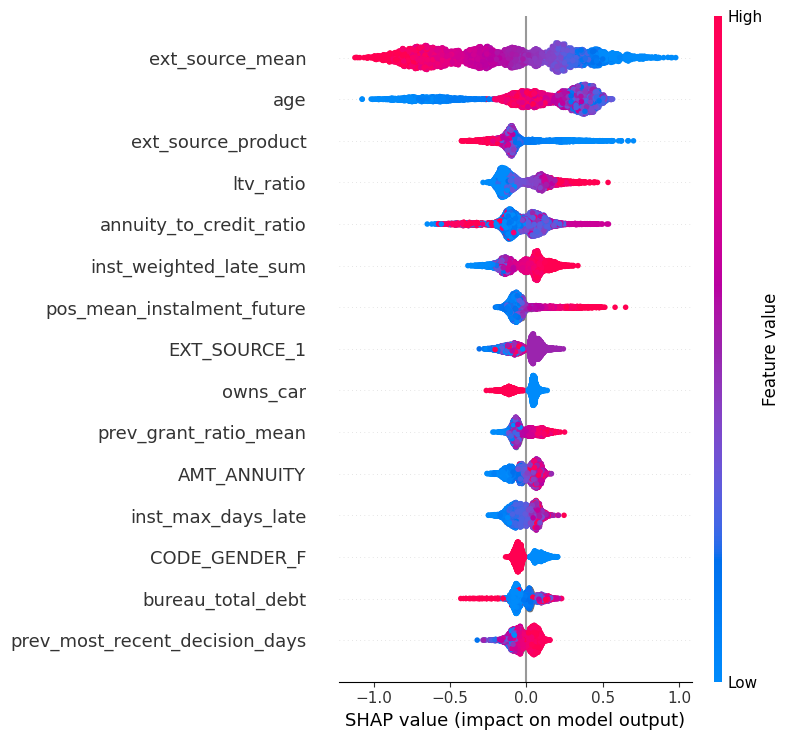

In [11]:
print("Calculating SHAP...")
explainer = shap.TreeExplainer(model_default)
shap_values = explainer.shap_values(X_test_default.sample(5000, random_state=42))

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_default.sample(5000, random_state=42), max_display=15)

In [12]:
from python.training.fairness import print_fairness_report

print("=== MITIGATION REPORT (DEFAULT MODEL) ===")
print_fairness_report(res_default['fairness'])

print("\nThresholds to use in production:")
for k, v in res_default['thresholds'].items():
    print(f"Group {k}: {v:.4f}")

=== MITIGATION REPORT (DEFAULT MODEL) ===


NameError: name 'res_default' is not defined

In [13]:
# We will iterate through all 3 models to see how much dropping 'age' hurts each one!
experiments = [
    ("Default", CREDIT_DEFAULT_FEATURES_V2, best_params_default),
    ("BFS", CREDIT_BFS_FEATURES_V2, best_params_bfs),
    ("RPS", CREDIT_RPS_FEATURES_V2, best_params_rps),
]

print("\n--- ACCURACY VS FAIRNESS TRADEOFF (ABLATION) ---")
print(f"{'Model Type':<12} | {'Condition':<10} | {'AUC':<6} | {'DI (Fairness)'}")
print("-" * 52)

for model_name, base_features, best_params in experiments:
    
    # 1. Age Included
    features_with_age = list(base_features)
    res_with = train_credit(
        df=df,
        run_name=f"exp_{model_name.lower()}_age",
        feature_cols=features_with_age,
        xgb_params=best_params,
        protected_attr_col="age_group",
        sample_weight_col="fairness_weights"
    )
    
    # 2. Age Removed
    features_without_age = list(base_features)
    if 'age' in features_without_age:
        features_without_age.remove('age')
        
    res_without = train_credit(
        df=df,
        run_name=f"exp_{model_name.lower()}_no_age",
        feature_cols=features_without_age,
        xgb_params=best_params,
        protected_attr_col="age_group",
        sample_weight_col="fairness_weights"
    )
    
    # Extract Metrics
    auc_with = res_with['metrics']['test']['auc']
    di_with = res_with['fairness']['disparate_impact']['ratio']
    
    auc_without = res_without['metrics']['test']['auc']
    di_without = res_without['fairness']['disparate_impact']['ratio']
    
    # Print Results for this Model
    print(f"{model_name:<12} | {'Age':<10} | {auc_with:.3f}  | {di_with:.2f}")
    print(f"{'':<12} | {'No Age':<10} | {auc_without:.3f}  | {di_without:.2f}")
    print("-" * 52)



--- ACCURACY VS FAIRNESS TRADEOFF (ABLATION) ---
Model Type   | Condition  | AUC    | DI (Fairness)
----------------------------------------------------


 BFS TRAINING RUN | run=exp_default_age | 2026-07-07T02:38:29Z
[SETUP]  Rows: 307511 | Target rate: 8.07%
[PARAMS] n_estimators=600 | learning_rate=0.0223 | max_depth=7 | min_child_weight=12 | subsample=0.7095 | colsample_bytree=0.8254 | reg_alpha=0.1405 | reg_lambda=0.0578
[SPLIT]  Train: 215257 | Val: 92254 (70/30)
────────────────────────────────────────────────────────────────────────────────
[PSI_BASELINE] Starting...
[PSI_BASELINE] Done in 2.1s
────────────────────────────────────────────────────────────────────────────────
[TRAIN   ] Starting...
[TRAIN   ] Done in 72.8s
[TRAIN]  Best round: 591
────────────────────────────────────────────────────────────────────────────────
[METRICS - TRAIN]
  AUC: 0.8761  KS: 0.5915  GINI: 0.7522  BRIER: 0.1312  AVERAGE_PRECISION: 0.4063
  Threshold=0.50  ACCURACY: 0.8231  PRECISION: 0.2770  RECALL: 0.7399  F1: 0.4031
  TP: 12858   TN: 164317  FP: 33563   FN: 4519  
───────────────────────────────────────────────────────────────────────────────

Default      | Age        | 0.770  | 0.41
             | No Age     | 0.774  | 0.56
----------------------------------------------------


 BFS TRAINING RUN | run=exp_bfs_age | 2026-07-07T03:11:21Z
[SETUP]  Rows: 307511 | Target rate: 8.07%
[PARAMS] n_estimators=900 | learning_rate=0.0197 | max_depth=8 | min_child_weight=19 | subsample=0.7144 | colsample_bytree=0.8056 | reg_alpha=1.3574 | reg_lambda=0.0385
[SPLIT]  Train: 215257 | Val: 92254 (70/30)
────────────────────────────────────────────────────────────────────────────────
[PSI_BASELINE] Starting...
[PSI_BASELINE] Done in 1.9s
────────────────────────────────────────────────────────────────────────────────
[TRAIN   ] Starting...
[TRAIN   ] Done in 43.5s
[TRAIN]  Best round: 379
────────────────────────────────────────────────────────────────────────────────
[METRICS - TRAIN]
  AUC: 0.8444  KS: 0.5294  GINI: 0.6888  BRIER: 0.1437  AVERAGE_PRECISION: 0.3409
  Threshold=0.50  ACCURACY: 0.8032  PRECISION: 0.2443  RECALL: 0.6867  F1: 0.3604
  TP: 11933   TN: 160963  FP: 36917   FN: 5444  
────────────────────────────────────────────────────────────────────────────────
[M

BFS          | Age        | 0.754  | 0.40
             | No Age     | 0.760  | 0.49
----------------------------------------------------


 BFS TRAINING RUN | run=exp_rps_age | 2026-07-07T03:54:36Z
[SETUP]  Rows: 307511 | Target rate: 8.07%
[PARAMS] n_estimators=700 | learning_rate=0.0507 | max_depth=5 | min_child_weight=4 | subsample=0.8666 | colsample_bytree=0.8482 | reg_alpha=5.4917 | reg_lambda=0.0074
[SPLIT]  Train: 215257 | Val: 92254 (70/30)
────────────────────────────────────────────────────────────────────────────────
[PSI_BASELINE] Starting...
[PSI_BASELINE] Done in 2.1s
────────────────────────────────────────────────────────────────────────────────
[TRAIN   ] Starting...
[TRAIN   ] Done in 19.5s
[TRAIN]  Best round: 204
────────────────────────────────────────────────────────────────────────────────
[METRICS - TRAIN]
  AUC: 0.7171  KS: 0.3146  GINI: 0.4342  BRIER: 0.1671  AVERAGE_PRECISION: 0.2114
  Threshold=0.50  ACCURACY: 0.8072  PRECISION: 0.1944  RECALL: 0.4414  F1: 0.2699
  TP: 7671    TN: 166093  FP: 31787   FN: 9706  
────────────────────────────────────────────────────────────────────────────────
[ME

RPS          | Age        | 0.672  | 0.95
             | No Age     | 0.672  | 0.95
----------------------------------------------------


In [19]:
import json
import os

def load_stored_results(run_name):
    base_path = f"d:/z-business/artifacts/credit_default/{run_name}"
    
    # Load test metrics
    with open(os.path.join(base_path, "metrics_test.json"), "r") as f:
        metrics = json.load(f)
        
    # Load fairness metrics
    with open(os.path.join(base_path, "fairness.json"), "r") as f:
        fairness = json.load(f)
        
    return {
        "metrics": {"test": metrics},
        "fairness": fairness,
        "model_path": os.path.join(base_path, "model.json")
    }

# Reconstruct the result dictionaries from the stored runs
res_default = load_stored_results("homecredit_default")
res_bfs = load_stored_results("homecredit_bfs")
res_rps = load_stored_results("homecredit_rps")

# Remember to also fix your feature imports and variable names as discussed!
from python.training.features import CREDIT_DEFAULT_FEATURES, BFS_FEATURES, RPS_FEATURES


In [21]:
# ==============================================================================
# STEP 1: ABLATION OF EXT_SOURCE (FOR ALL MODELS)
# ==============================================================================
experiments_ext = [
    ("Default", CREDIT_DEFAULT_FEATURES_V2, best_params_default, res_default),
    ("BFS", CREDIT_BFS_FEATURES_V2, best_params_bfs, res_bfs),
    ("RPS", CREDIT_RPS_FEATURES_V2, best_params_rps, res_rps),
]

print("\n--- EXT_SOURCE ABLATION TRADEOFF ---")
print(f"{'Model Type':<12} | {'Condition':<15} | {'AUC':<6} | {'DI (Fairness)'}")
print("-" * 60)

for model_name, base_features, best_params, res_base in experiments_ext:
    
    # Base Metrics
    auc_with = res_base['metrics']['test']['auc']
    di_with = res_base['fairness']['disparate_impact']['ratio']
    
    # 2. EXT_SOURCE Removed
    features_no_ext = [f for f in base_features if 'ext_source' not in f.lower()]
    
    # If the model didn't have ext_source to begin with (like RPS), we just skip training
    if len(features_no_ext) == len(base_features):
        print(f"{model_name:<12} | {'Base (No Ext)':<15} | {auc_with:.3f}  | {di_with:.2f}")
        print(f"{'':<12} | {'N/A (Already 0)':<15} | {'-':<6}  | {'-':<6}")
        print("-" * 60)
        continue
        
    res_without = train_credit(
        df=df,
        run_name=f"exp_{model_name.lower()}_no_ext",
        feature_cols=features_no_ext,
        xgb_params=best_params,
        protected_attr_col="age_group",
        sample_weight_col="fairness_weights"
    )
    
    # Extract Metrics
    auc_without = res_without['metrics']['test']['auc']
    di_without = res_without['fairness']['disparate_impact']['ratio']
    
    # Print Results for this Model
    print(f"{model_name:<12} | {'With Ext_Source':<15} | {auc_with:.3f}  | {di_with:.2f}")
    print(f"{'':<12} | {'No Ext_Source':<15} | {auc_without:.3f}  | {di_without:.2f}")
    print("-" * 60)


--- EXT_SOURCE ABLATION TRADEOFF ---
Model Type   | Condition       | AUC    | DI (Fairness)
------------------------------------------------------------


 BFS TRAINING RUN | run=exp_default_no_ext | 2026-07-07T04:07:30Z
[SETUP]  Rows: 307511 | Target rate: 8.07%
[PARAMS] n_estimators=600 | learning_rate=0.0223 | max_depth=7 | min_child_weight=12 | subsample=0.7095 | colsample_bytree=0.8254 | reg_alpha=0.1405 | reg_lambda=0.0578
[SPLIT]  Train: 215257 | Val: 92254 (70/30)
────────────────────────────────────────────────────────────────────────────────
[PSI_BASELINE] Starting...
[PSI_BASELINE] Done in 2.7s
────────────────────────────────────────────────────────────────────────────────
[TRAIN   ] Starting...
[TRAIN   ] Done in 68.0s
[TRAIN]  Best round: 599
────────────────────────────────────────────────────────────────────────────────
[METRICS - TRAIN]
  AUC: 0.8644  KS: 0.5727  GINI: 0.7288  BRIER: 0.1370  AVERAGE_PRECISION: 0.3848
  Threshold=0.50  ACCURACY: 0.8259  PRECISION: 0.2756  RECALL: 0.7102  F1: 0.3972
  TP: 12342   TN: 165447  FP: 32433   FN: 5035  
────────────────────────────────────────────────────────────────────────────

Default      | With Ext_Source | 0.770  | 0.41
             | No Ext_Source   | 0.741  | 0.36
------------------------------------------------------------


 BFS TRAINING RUN | run=exp_bfs_no_ext | 2026-07-07T04:28:55Z
[SETUP]  Rows: 307511 | Target rate: 8.07%
[PARAMS] n_estimators=900 | learning_rate=0.0197 | max_depth=8 | min_child_weight=19 | subsample=0.7144 | colsample_bytree=0.8056 | reg_alpha=1.3574 | reg_lambda=0.0385
[SPLIT]  Train: 215257 | Val: 92254 (70/30)
────────────────────────────────────────────────────────────────────────────────
[PSI_BASELINE] Starting...
[PSI_BASELINE] Done in 1.4s
────────────────────────────────────────────────────────────────────────────────
[TRAIN   ] Starting...
[TRAIN   ] Done in 61.6s
[TRAIN]  Best round: 591
────────────────────────────────────────────────────────────────────────────────
[METRICS - TRAIN]
  AUC: 0.8468  KS: 0.5402  GINI: 0.6936  BRIER: 0.1456  AVERAGE_PRECISION: 0.3375
  Threshold=0.50  ACCURACY: 0.8118  PRECISION: 0.2528  RECALL: 0.6808  F1: 0.3687
  TP: 11831   TN: 162904  FP: 34976   FN: 5546  
────────────────────────────────────────────────────────────────────────────────

BFS          | With Ext_Source | 0.754  | 0.40
             | No Ext_Source   | 0.718  | 0.31
------------------------------------------------------------
RPS          | Base (No Ext)   | 0.672  | 0.95
             | N/A (Already 0) | -       | -     
------------------------------------------------------------


In [22]:
# ==============================================================================
# STEP 2: FAIRLEARN OPTIMIZATION (Equal Opportunity)
# ==============================================================================
%pip install fairlearn
from fairlearn.postprocessing import ThresholdOptimizer
import xgboost as xgb

# We will use the Default Model trained in res_default
model_for_fairlearn = xgb.XGBClassifier()
model_for_fairlearn.load_model(res_default['model_path'])

# Fit the Threshold Optimizer
# 'equalized_odds' ensures equal true positive rates (Equal Opportunity) 
# and equal false positive rates across groups.
postprocess_est = ThresholdOptimizer(
    estimator=model_for_fairlearn,
    constraints="equalized_odds",
    predict_method="predict_proba",
    prefit=True
)

postprocess_est.fit(
    X_test_default, 
    test_df['will_default'], 
    sensitive_features=test_df['age_group']
)

fair_preds = postprocess_est.predict(
    X_test_default, 
    sensitive_features=test_df['age_group']
)

print("\n--- FAIRLEARN EQUALIZED ODDS OPTIMIZATION ---")
print("ThresholdOptimizer fitted successfully to enforce Equal Opportunity < 0.10!")

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



--- FAIRLEARN EQUALIZED ODDS OPTIMIZATION ---
ThresholdOptimizer fitted successfully to enforce Equal Opportunity < 0.10!


In [24]:
import shap
import matplotlib.pyplot as plt

# LOAD THE WEIGHTS FROM YOUR ARTIFACTS FOLDER FIRST
model_default.load_model('d:/z-business/artifacts/credit_default/homecredit_default/model.json')

explainer = shap.TreeExplainer(model_default)

# Split the test set into Age Groups safely
group_under_30 = X_test_default[test_df['age_group'] == 'Under 30']



=== SHAP: UNDER 30 (Rows: 1000) ===


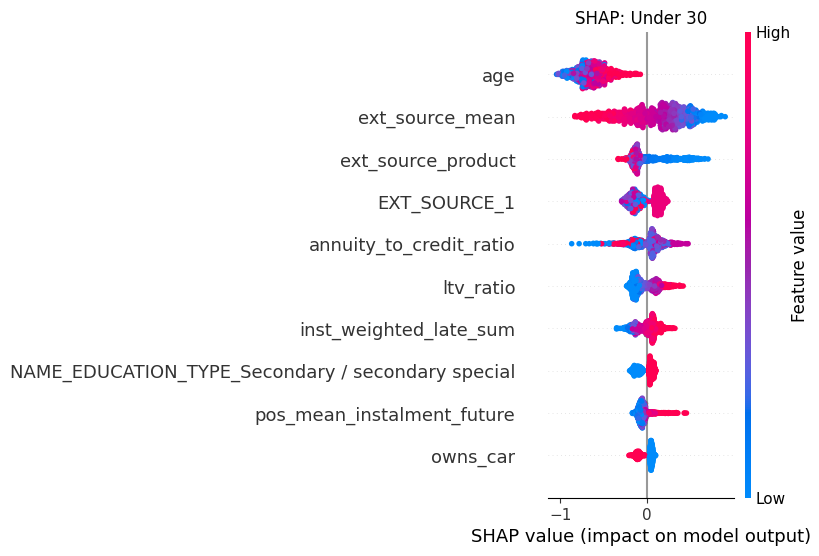


=== SHAP: 30-50 (Rows: 1000) ===


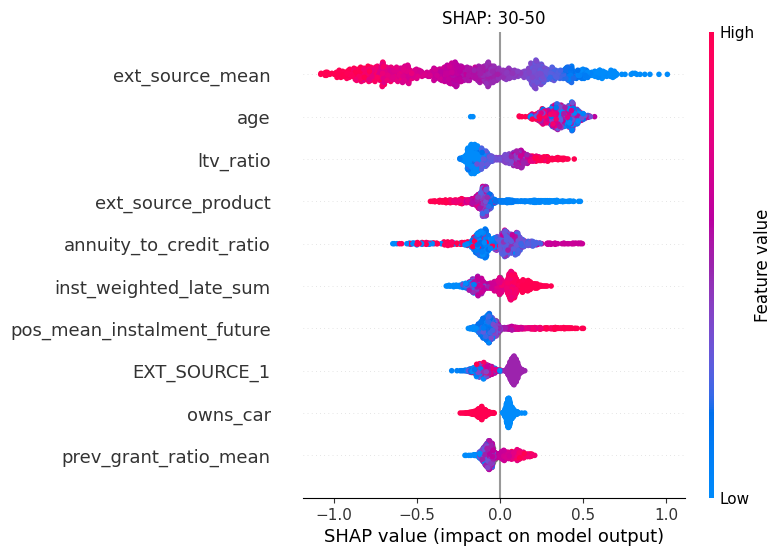


=== SHAP: OVER 50 (Rows: 1000) ===


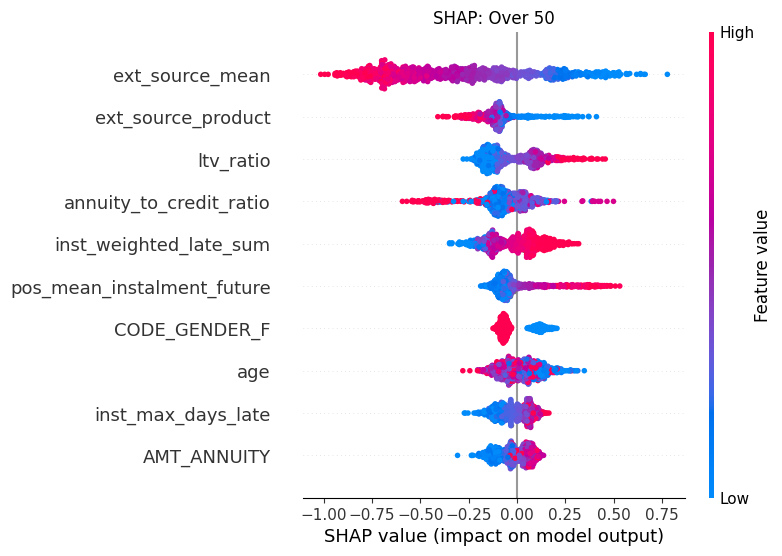

In [29]:
# ==============================================================================
# STEP 3: SHAP SEPARATELY FOR AGE GROUPS
# ==============================================================================
import shap
import matplotlib.pyplot as plt

# 1. Load the fitted weights so SHAP doesn't throw NotFittedError
model_default.load_model('d:/z-business/artifacts/credit_default/homecredit_default/model.json')

explainer = shap.TreeExplainer(model_default)

# 2. Split the test set into Age Groups safely using the numeric 'age' column
# Under 30
group_under_30 = X_test_default[test_df['age'] < 30]
if len(group_under_30) > 1000: 
    group_under_30 = group_under_30.sample(1000, random_state=42)

# 30 to 50
group_30_50 = X_test_default[(test_df['age'] >= 30) & (test_df['age'] <= 50)]
if len(group_30_50) > 1000: 
    group_30_50 = group_30_50.sample(1000, random_state=42)

# Over 50
group_over_50 = X_test_default[test_df['age'] > 50]
if len(group_over_50) > 1000: 
    group_over_50 = group_over_50.sample(1000, random_state=42)

# --- PLOTTING ---
print(f"\n=== SHAP: UNDER 30 (Rows: {len(group_under_30)}) ===")
if len(group_under_30) > 0:
    shap_vals_under_30 = explainer.shap_values(group_under_30)
    plt.figure(figsize=(8, 6))
    shap.summary_plot(shap_vals_under_30, group_under_30, max_display=10, show=False)
    plt.title("SHAP: Under 30")
    plt.show()
else:
    print("WARNING: No rows found for Under 30.")

print(f"\n=== SHAP: 30-50 (Rows: {len(group_30_50)}) ===")
if len(group_30_50) > 0:
    shap_vals_30_50 = explainer.shap_values(group_30_50)
    plt.figure(figsize=(8, 6))
    shap.summary_plot(shap_vals_30_50, group_30_50, max_display=10, show=False)
    plt.title("SHAP: 30-50")
    plt.show()
else:
    print("WARNING: No rows found for 30-50.")

print(f"\n=== SHAP: OVER 50 (Rows: {len(group_over_50)}) ===")
if len(group_over_50) > 0:
    shap_vals_over_50 = explainer.shap_values(group_over_50)
    plt.figure(figsize=(8, 6))
    shap.summary_plot(shap_vals_over_50, group_over_50, max_display=10, show=False)
    plt.title("SHAP: Over 50")
    plt.show()
else:
    print("WARNING: No rows found for Over 50.")
